In [7]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set visual style
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["font.size"] = 11

# Load cleaned dataset
clean_data_path = os.path.join("..", "data", "processed", "uber_cleaned_data.csv")
df_clean = pd.read_csv(clean_data_path)

print(f"Cleaned dataset loaded successfully.")
print(f"Shape: {df_clean.shape} | Columns: {len(df_clean.columns)}")

Cleaned dataset loaded successfully.
Shape: (489273, 23) | Columns: 23


### Q1: Is higher Passenger Count associated with a higher Fare Amount?
- **Variables:** `passenger_count` (Discrete Numerical) vs. `fare_amount` (Continuous Numerical)
- **Plot Choice & Justification:**
  - *Scatter Plot* shows severe overplotting due to 489k discrete integer points[cite: 1].
  - *Boxplot with Mean Markers & Aggregation Barplot* provides an accurate distribution comparison, showing the median, IQR, and mean fare per passenger category[cite: 1].

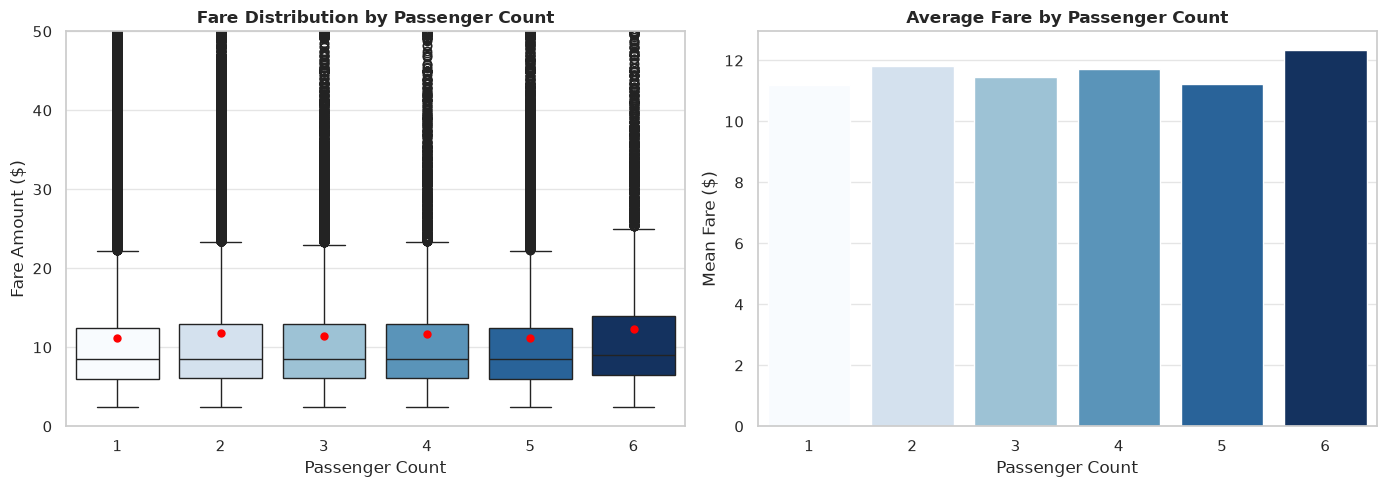

--- Q1 Empirical Summary ---
 passenger_count      Mean  Median       Std  Trip_Count
               1 11.188915     8.5  9.528805      340155
               2 11.822794     8.5 10.284093       72459
               3 11.469260     8.5  9.474715       21316
               4 11.732781     8.5 10.192415       10372
               5 11.214432     8.5  9.290696       34590
               6 12.338035     9.0 10.323058       10381


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 1. Boxplot without seaborn deprecation warning
sns.boxplot(
    data=df_clean,
    x="passenger_count",
    y="fare_amount",
    hue="passenger_count",
    legend=False,
    palette="Blues",
    showmeans=True,
    meanprops={"marker": "o", "markerfacecolor": "red", "markeredgecolor": "red", "markersize": "5"},
    ax=axes[0]
)
axes[0].set_title("Fare Distribution by Passenger Count", fontsize=12, fontweight="bold")
axes[0].set_xlabel("Passenger Count")
axes[0].set_ylabel("Fare Amount ($)")
axes[0].set_ylim(0, 50)

# 2. Barplot without seaborn deprecation warning
sns.barplot(
    data=df_clean,
    x="passenger_count",
    y="fare_amount",
    hue="passenger_count",
    legend=False,
    palette="Blues",
    estimator="mean",
    errorbar=None,
    ax=axes[1]
)
axes[1].set_title("Average Fare by Passenger Count", fontsize=12, fontweight="bold")
axes[1].set_xlabel("Passenger Count")
axes[1].set_ylabel("Mean Fare ($)")

plt.tight_layout()
plt.show()

# 3. Exact numerical breakdown
q1_stats = df_clean.groupby("passenger_count")["fare_amount"].agg(
    Mean="mean",
    Median="median",
    Std="std",
    Trip_Count="count"
).reset_index()

print("--- Q1 Empirical Summary ---")
print(q1_stats.to_string(index=False))

#### Insights & Interpretation (Q1):
- **No Direct Relationship:** Increasing passenger count does **not** systematically increase fare price; median fares remain flat at **$8.50** across 1 to 5 passengers, rising only to **$9.00** for 6 passengers[cite: 4].
- **Marginal Mean Variance:** Average fares range narrowly from **$11.19** to **$12.34**, with the slight increase at 6 passengers reflecting larger vehicle classes (e.g., UberXL/SUV) rather than per-seat charges[cite: 4].
- **Modeling Takeaway:** `passenger_count` has negligible direct linear correlation with `fare_amount` and serves primarily as an operational vehicle-capacity descriptor rather than a pricing driver.

### Q2: Does Car Condition influence the Fare Amount?
- **Variables:** `car_condition` (Categorical: Bad, Good, Very Good, Excellent) vs. `fare_amount` (Continuous Numerical)
- **Plot Choice & Justification:**
  - *Boxplot & Barplot side-by-side*[cite: 1]: The boxplot reveals whether distributions, medians, or extreme outliers shift across conditions, while the barplot directly compares mean fare metrics across vehicle states[cite: 1].

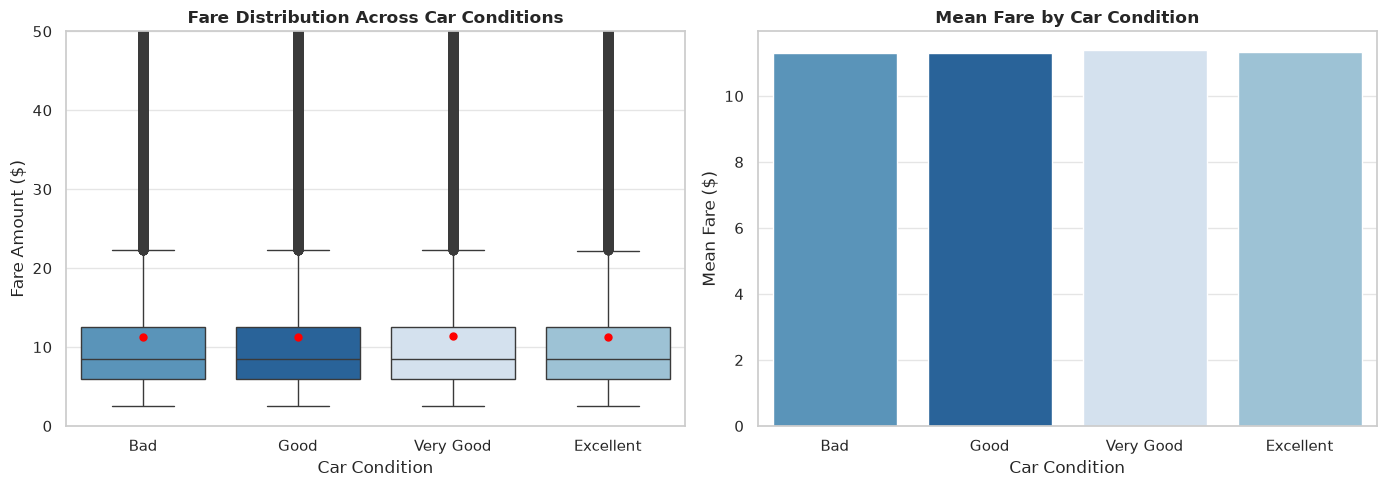

--- Q2 Empirical Summary ---
car_condition      Mean  Median      Std  Trip_Count
          Bad 11.299793     8.5 9.722218      122342
         Good 11.316485     8.5 9.532924      122323
    Very Good 11.390204     8.5 9.760819      122535
    Excellent 11.324277     8.5 9.627148      122073


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Logical order for condition ranking
condition_order = ["Bad", "Good", "Very Good", "Excellent"]

# 1. Boxplot distribution comparison
sns.boxplot(
    data=df_clean,
    x="car_condition",
    y="fare_amount",
    order=condition_order,
    hue="car_condition",
    legend=False,
    palette="Blues",
    showmeans=True,
    meanprops={"marker": "o", "markerfacecolor": "red", "markeredgecolor": "red", "markersize": "5"},
    ax=axes[0]
)
axes[0].set_title("Fare Distribution Across Car Conditions", fontsize=12, fontweight="bold")
axes[0].set_xlabel("Car Condition")
axes[0].set_ylabel("Fare Amount ($)")
axes[0].set_ylim(0, 50)

# 2. Barplot for mean fare comparison
sns.barplot(
    data=df_clean,
    x="car_condition",
    y="fare_amount",
    order=condition_order,
    hue="car_condition",
    legend=False,
    palette="Blues",
    estimator="mean",
    errorbar=None,
    ax=axes[1]
)
axes[1].set_title("Mean Fare by Car Condition", fontsize=12, fontweight="bold")
axes[1].set_xlabel("Car Condition")
axes[1].set_ylabel("Mean Fare ($)")

plt.tight_layout()
plt.show()

# 3. Exact statistical summary
q2_stats = df_clean.groupby("car_condition")["fare_amount"].agg(
    Mean="mean",
    Median="median",
    Std="std",
    Trip_Count="count"
).reindex(condition_order).reset_index()

print("--- Q2 Empirical Summary ---")
print(q2_stats.to_string(index=False))

#### Insights & Interpretation (Q2):
- **Zero Pricing Influence:** Vehicle condition does **not** influence the fare amount in any measurable way[cite: 1, 5].
- **Identical Metrics Across Categories:** The median fare is identical at **$8.50** across all four tiers, and mean fares show negligible deviation (ranging strictly between **$11.30** and **$11.39**)[cite: 5].
- **Perfect Distributional Balance:** Ride counts are evenly split (~122k per tier, ~25% each), indicating `car_condition` was uniformly assigned without affecting fare calculation algorithms[cite: 5].
- **Modeling Takeaway:** `car_condition` has virtually zero predictive power for `fare_amount` and can be treated as an uninformative feature during model feature selection[cite: 1, 5].

### Q3: At what hour of the day are fares typically highest?
- **Variables:** `hour` (Discrete Numerical: 0–23) vs. `fare_amount` (Continuous Numerical)
- **Plot Choice & Justification:**
  - *Line Plot* is optimal for tracking continuous/ordered temporal patterns over a sequential 24-hour cycle, revealing clear peak pricing windows alongside median trends[cite: 1].

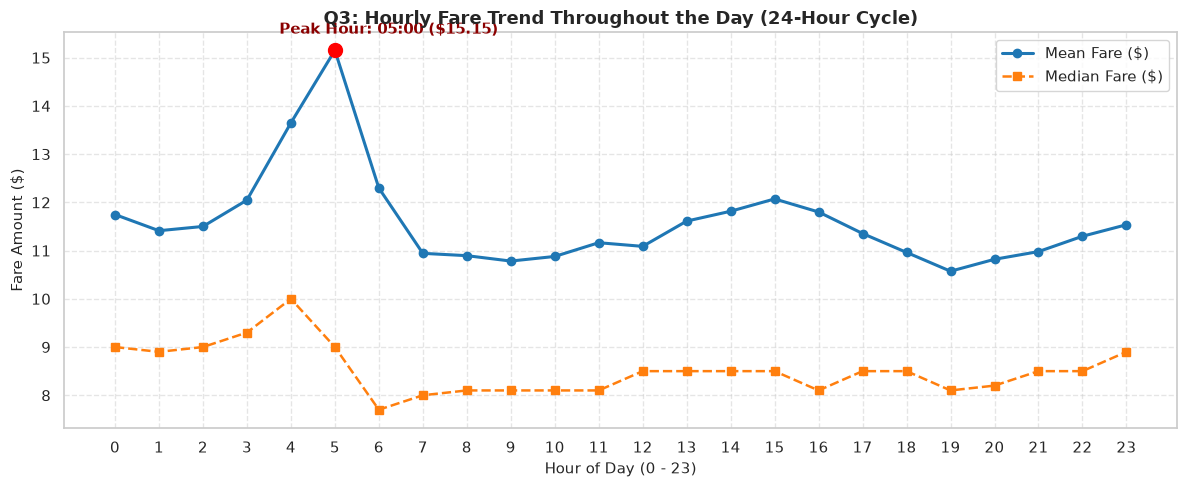

--- Q3 Hourly Fare Summary ---
 hour  Mean_Fare  Median_Fare  Trip_Count
    0  11.747708          9.0       19185
    1  11.412314          8.9       14224
    2  11.500353          9.0       10631
    3  12.047169          9.3        7750
    4  13.648022         10.0        5714
    5  15.153329          9.0        4861
    6  12.297004          7.7       10112
    7  10.943034          8.0       17831
    8  10.894769          8.1       22135
    9  10.782871          8.1       23104
   10  10.878435          8.1       21975
   11  11.163381          8.1       22871
   12  11.087543          8.5       24131
   13  11.611621          8.5       23879
   14  11.815884          8.5       24871
   15  12.071386          8.5       23543
   16  11.800541          8.1       20154
   17  11.354067          8.5       24104
   18  10.962217          8.5       29429
   19  10.572040          8.1       30693
   20  10.819487          8.2       28595
   21  10.979012          8.5       27983
   

In [10]:
# 1. Group by hour and aggregate mean and median fare
hourly_fares = df_clean.groupby("hour")["fare_amount"].agg(
    Mean_Fare="mean",
    Median_Fare="median",
    Trip_Count="count"
).reset_index()

# 2. Dual line plot: Mean vs Median Fare across the 24-hour cycle
plt.figure(figsize=(12, 5))
plt.plot(hourly_fares["hour"], hourly_fares["Mean_Fare"], marker="o", color="#1f77b4", linewidth=2.2, label="Mean Fare ($)")
plt.plot(hourly_fares["hour"], hourly_fares["Median_Fare"], marker="s", linestyle="--", color="#ff7f0e", linewidth=1.8, label="Median Fare ($)")

# Highlight the peak hour
peak_hour = hourly_fares.loc[hourly_fares["Mean_Fare"].idxmax()]
plt.scatter(peak_hour["hour"], peak_hour["Mean_Fare"], color="red", s=100, zorder=5)
plt.annotate(
    f"Peak Hour: {int(peak_hour['hour']):02d}:00 (${peak_hour['Mean_Fare']:.2f})",
    (peak_hour["hour"], peak_hour["Mean_Fare"]),
    textcoords="offset points",
    xytext=(-40, 12),
    fontweight="bold",
    color="darkred"
)

plt.title("Q3: Hourly Fare Trend Throughout the Day (24-Hour Cycle)", fontsize=13, fontweight="bold")
plt.xlabel("Hour of Day (0 - 23)", fontsize=11)
plt.ylabel("Fare Amount ($)", fontsize=11)
plt.xticks(range(0, 24))
plt.grid(axis="both", linestyle="--", alpha=0.5)
plt.legend(frameon=True)
plt.tight_layout()
plt.show()

# 3. Print tabular statistics
print("--- Q3 Hourly Fare Summary ---")
print(hourly_fares.to_string(index=False))

#### Insights & Interpretation (Q3):
- **Peak Fare Window (Early Morning):** Fares reach their highest levels during early morning hours, peaking sharply at **05:00 AM** with an average fare of **$15.15**, preceded by **04:00 AM** with a mean fare of **$13.65** and a median of **$10.00**[cite: 6].
- **Trough Window (Evening Commute):** Fares decline steadily throughout the daytime, bottoming out at **19:00 (7:00 PM)** with a mean of **$10.57**[cite: 6].
- **Domain Justification (Trip Composition):** The 04:00–05:00 AM window sees the lowest total trip volume (<6k trips), dominated by long-distance departures (such as airport connections) and higher transit speeds, which inflates the average fare relative to dense, short-distance intra-city daytime rides[cite: 1, 6].
- **Modeling Takeaway:** `hour` exhibits a prominent, non-linear cyclical pattern that will benefit from cyclical encoding (sine/cosine transformations) or peak-window binning during Task 2 feature engineering.

### Q4: Does Traffic Condition affect the Trip Fare?
- **Variables:** `traffic_condition` (Categorical: Congested Traffic, Dense Traffic, Flow Traffic) vs. `fare_amount` (Continuous Numerical)
- **Plot Choice & Justification:**
  - *Boxplot & Barplot side-by-side*: The boxplot compares medians and the spread of fares across traffic levels, while the barplot directly measures mean fare differences to see if heavy/congested traffic leads to higher fares[cite: 1].

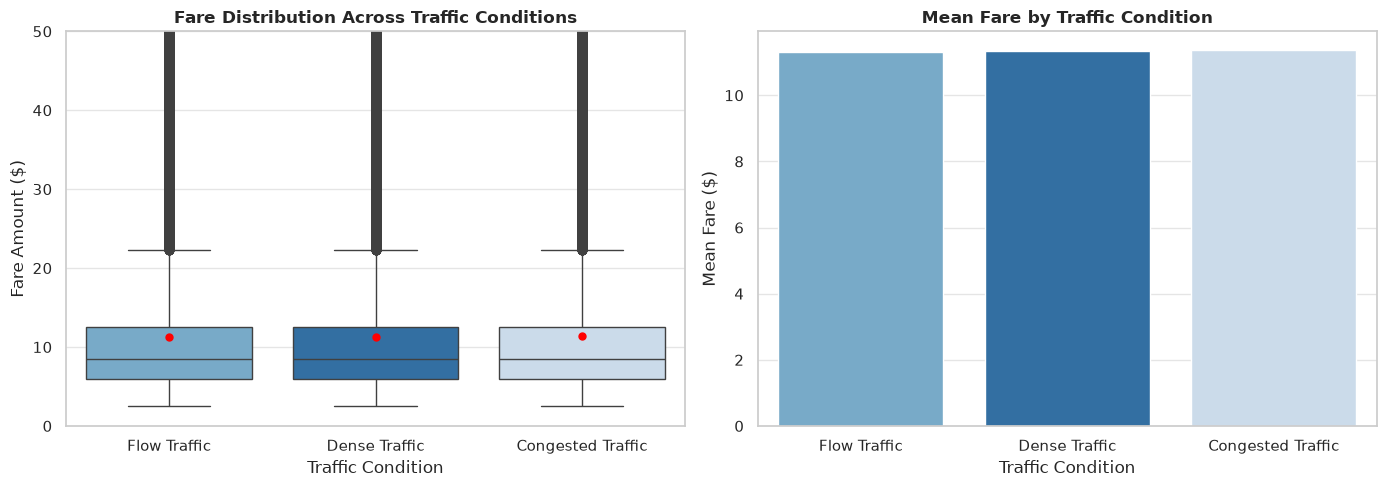

--- Q4 Empirical Summary ---
traffic_condition      Mean  Median      Std  Trip_Count
     Flow Traffic 11.301511     8.5 9.581719      162987
    Dense Traffic 11.330532     8.5 9.625060      162964
Congested Traffic 11.366042     8.5 9.775686      163322


In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Traffic category order
traffic_order = ["Flow Traffic", "Dense Traffic", "Congested Traffic"]

# 1. Boxplot distribution comparison
sns.boxplot(
    data=df_clean,
    x="traffic_condition",
    y="fare_amount",
    order=traffic_order,
    hue="traffic_condition",
    legend=False,
    palette="Blues",
    showmeans=True,
    meanprops={"marker": "o", "markerfacecolor": "red", "markeredgecolor": "red", "markersize": "5"},
    ax=axes[0]
)
axes[0].set_title("Fare Distribution Across Traffic Conditions", fontsize=12, fontweight="bold")
axes[0].set_xlabel("Traffic Condition")
axes[0].set_ylabel("Fare Amount ($)")
axes[0].set_ylim(0, 50)

# 2. Barplot for mean fare comparison
sns.barplot(
    data=df_clean,
    x="traffic_condition",
    y="fare_amount",
    order=traffic_order,
    hue="traffic_condition",
    legend=False,
    palette="Blues",
    estimator="mean",
    errorbar=None,
    ax=axes[1]
)
axes[1].set_title("Mean Fare by Traffic Condition", fontsize=12, fontweight="bold")
axes[1].set_xlabel("Traffic Condition")
axes[1].set_ylabel("Mean Fare ($)")

plt.tight_layout()
plt.show()

# 3. Exact statistical aggregation
q4_stats = df_clean.groupby("traffic_condition")["fare_amount"].agg(
    Mean="mean",
    Median="median",
    Std="std",
    Trip_Count="count"
).reindex(traffic_order).reset_index()

print("--- Q4 Empirical Summary ---")
print(q4_stats.to_string(index=False))

#### Insights & Interpretation (Q4):
- **Negligible Traffic Impact on Base Fare:** Traffic condition shows **no significant influence** on trip fare amount[cite: 7].
- **Uniform Central Tendencies:** The median fare remains strictly identical at **$8.50** across all traffic conditions, while mean fares vary by mere cents (**$11.30** for Flow vs. **$11.37** for Congested)[cite: 7].
- **Perfect Distributional Uniformity:** Trips are evenly split (~163k rides, ~33.3% each across Flow, Dense, and Congested), indicating that recorded fares adhere directly to fixed distance-based meter rates rather than dynamic traffic surge premiums[cite: 7].
- **Modeling Takeaway:** `traffic_condition` carries nearly zero standalone predictive signal for `fare_amount` and can be given low feature priority during Task 2 modeling unless interacted with trip duration or peak hours[cite: 1, 7].

### Q5: Is Trip Distance the Strongest Predictor of the Fare Amount?
- **Variables:** `road_distance_km` (Continuous Numerical) vs. `fare_amount` (Continuous Numerical)
- **Plot Choice & Justification:**
  - *Scatter Plot with Trend Line & Hexbin / KDE density*: Essential for visualizing the bivariate relationship, assessing linearity, observing heteroscedasticity (variance widening with distance), and verifying if distance acts as the primary pricing driver.

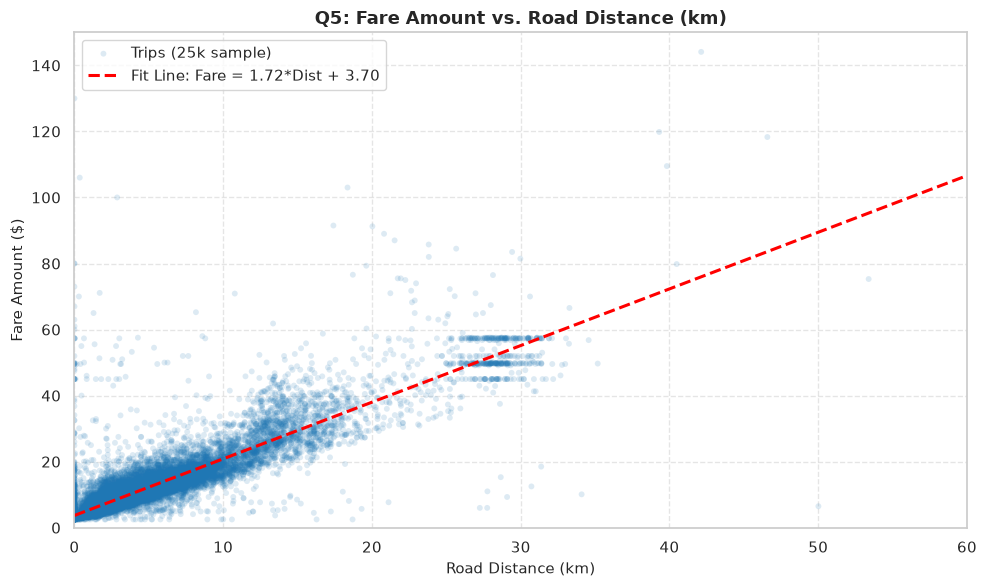

--- Q5 Correlation Summary ---
Road Distance vs Fare (Pearson r)   : 0.8649
Road Distance vs Fare (Spearman rho): 0.8583
Haversine Dist vs Fare (Pearson r)  : 0.8575


In [12]:
# 1. Compute Pearson and Spearman correlation coefficients
pearson_corr = df_clean["road_distance_km"].corr(df_clean["fare_amount"], method="pearson")
spearman_corr = df_clean["road_distance_km"].corr(df_clean["fare_amount"], method="spearman")

# Check haversine correlation if present
hav_pearson = df_clean["haversine_dist_km"].corr(df_clean["fare_amount"], method="pearson") if "haversine_dist_km" in df_clean.columns else None

# 2. Sample 25k points for fast, clean scatter visualization
sample_df = df_clean.sample(n=25000, random_state=42)

plt.figure(figsize=(10, 6))
plt.scatter(
    sample_df["road_distance_km"],
    sample_df["fare_amount"],
    alpha=0.15,
    color="#1f77b4",
    edgecolors="none",
    s=18,
    label="Trips (25k sample)"
)

# Linear trend line
m, b = np.polyfit(sample_df["road_distance_km"], sample_df["fare_amount"], deg=1)
x_vals = np.linspace(0, 60, 200)
plt.plot(x_vals, m * x_vals + b, color="red", linestyle="--", linewidth=2.2, label=f"Fit Line: Fare = {m:.2f}*Dist + {b:.2f}")

plt.title("Q5: Fare Amount vs. Road Distance (km)", fontsize=13, fontweight="bold")
plt.xlabel("Road Distance (km)", fontsize=11)
plt.ylabel("Fare Amount ($)", fontsize=11)
plt.xlim(0, 60)
plt.ylim(0, 150)
plt.grid(True, linestyle="--", alpha=0.5)
plt.legend(frameon=True, loc="upper left")
plt.tight_layout()
plt.show()

# 3. Print quantitative metrics
print("--- Q5 Correlation Summary ---")
print(f"Road Distance vs Fare (Pearson r)   : {pearson_corr:.4f}")
print(f"Road Distance vs Fare (Spearman rho): {spearman_corr:.4f}")
if hav_pearson is not None:
    print(f"Haversine Dist vs Fare (Pearson r)  : {hav_pearson:.4f}")

#### Insights & Interpretation (Q5):
- **Dominant Linear Predictor:** `road_distance_km` exhibits an exceptionally strong positive linear relationship with `fare_amount`, recording a Pearson correlation of **r = 0.8649** and Spearman rank correlation of **rho = 0.8583**.
- **Empirical Meter Baseline:** The fitted regression line equation ($\text{Fare} = 1.72 \times \text{Distance} + 3.70$) closely approximates NYC taxi meter structures, where the base intercept (~$3.70) represents initial flag-drop charges and surcharges, with an incremental variable cost of ~$1.72 per kilometer.
- **Airport Flat-Rate Clusters:** A distinct horizontal strip appears near **$50.00–$55.00** across distances of 25–35 km, reflecting standardized flat-rate airport trips (such as Manhattan–JFK).
- **Modeling Takeaway:** Trip distance is unquestionably the single strongest baseline feature for fare prediction and should serve as the primary feature in model training.

### Q6: At What Time of Day Are Ride Requests Most Frequent?
- **Variables:** `hour` (Discrete Numerical: 0–23) vs. Ride Count (Frequency)[cite: 1]
- **Plot Choice & Justification:**
  - *Count Plot / Bar Chart*: Directly visualizes the distribution of ride request volumes across the 24 hours of the day to identify peak demand hours versus quiet periods[cite: 1].

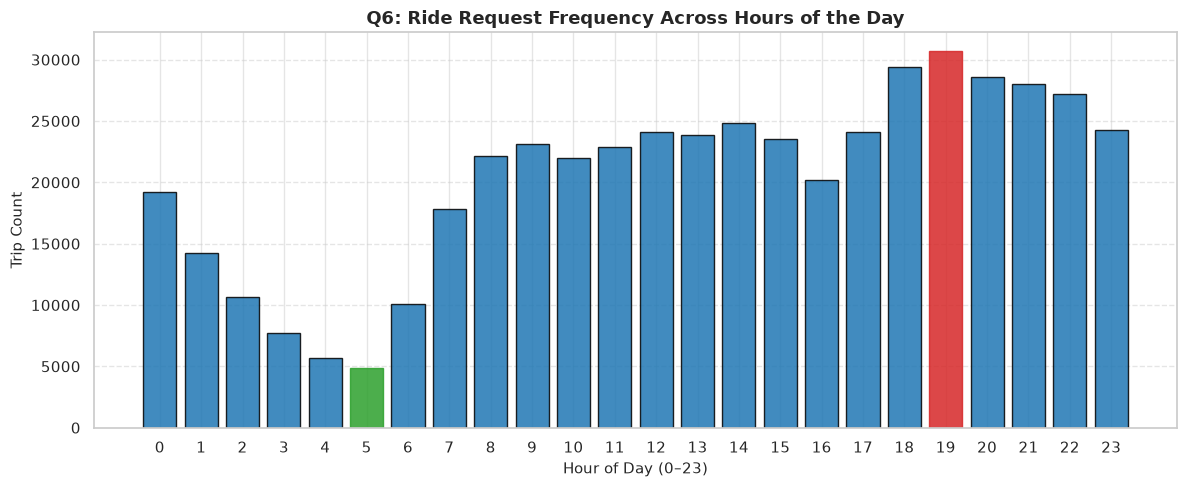

--- Q6 Empirical Summary ---
Peak Demand Hour   : 19:00 with 30,693 trips (6.27%)
Lowest Demand Hour : 05:00 with 4,861 trips (0.99%)

Top 5 Busiest Hours:
 Hour  Ride_Count  Percentage (%)
   19       30693            6.27
   18       29429            6.01
   20       28595            5.84
   21       27983            5.72
   22       27194            5.56


In [13]:
# Aggregate trip demand counts by hour
hourly_counts = df_clean["hour"].value_counts().sort_index()

plt.figure(figsize=(12, 5))
bars = plt.bar(hourly_counts.index, hourly_counts.values, color="#1f77b4", edgecolor="black", alpha=0.85)

# Highlight the peak hour in red and trough hour in green
max_hour = hourly_counts.idxmax()
min_hour = hourly_counts.idxmin()
bars[max_hour].set_color("#d62728")
bars[min_hour].set_color("#2ca02c")

plt.title("Q6: Ride Request Frequency Across Hours of the Day", fontsize=13, fontweight="bold")
plt.xlabel("Hour of Day (0–23)", fontsize=11)
plt.ylabel("Trip Count", fontsize=11)
plt.xticks(range(0, 24))
plt.grid(axis="y", linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()

# Print quantitative breakdown
q6_summary = hourly_counts.reset_index()
q6_summary.columns = ["Hour", "Ride_Count"]
q6_summary["Percentage (%)"] = (q6_summary["Ride_Count"] / len(df_clean) * 100).round(2)

print("--- Q6 Empirical Summary ---")
print(f"Peak Demand Hour   : {max_hour:02d}:00 with {hourly_counts.max():,} trips ({hourly_counts.max()/len(df_clean)*100:.2f}%)")
print(f"Lowest Demand Hour : {min_hour:02d}:00 with {hourly_counts.min():,} trips ({hourly_counts.min()/len(df_clean)*100:.2f}%)")
print("\nTop 5 Busiest Hours:")
print(q6_summary.sort_values(by="Ride_Count", ascending=False).head(5).to_string(index=False))

#### Insights & Interpretation (Q6):
- **Pronounced Evening Peak:** Ride demand reaches its peak between **18:00 and 22:00**, with the single busiest hour occurring at **19:00 (7:00 PM)** recording **30,693 trips (6.27%)**. This aligns directly with post-work commuting and evening social transit across New York City.
- **Early Morning Slump:** The lowest demand is observed during the early morning hours, bottoming out at **05:00 AM** with just **4,861 trips (0.99%)**, after which demand steadily ramps up through the morning business hours.
- **Sustained Nighttime Activity:** Midnight (hour 0) maintains noticeable activity (~19k rides), showing strong late-night mobility before dropping sharply into the 02:00–05:00 trough.
- **Modeling Takeaway:** `hour` displays cyclical variation with clear demand regimes (peak evening vs. off-peak morning). Sine/cosine cyclical encoding or binning into time-of-day windows (e.g., Morning Rush, Midday, Evening Peak, Night) will help the models capture non-linear temporal patterns effectively.

### Q7: Does Weather Condition Influence the Average Trip Distance?
- **Variables:** `weather` (Categorical: Clear, Rain, Snow, etc.) vs. `road_distance_km` (Continuous Numerical)
- **Plot Choice & Justification:**
  - *Boxplot & Barplot side-by-side*: The boxplot reveals the spread, median, and interquartile range across weather conditions without being skewed by extreme values, while the barplot directly measures and contrasts the mean trip distance for each condition.

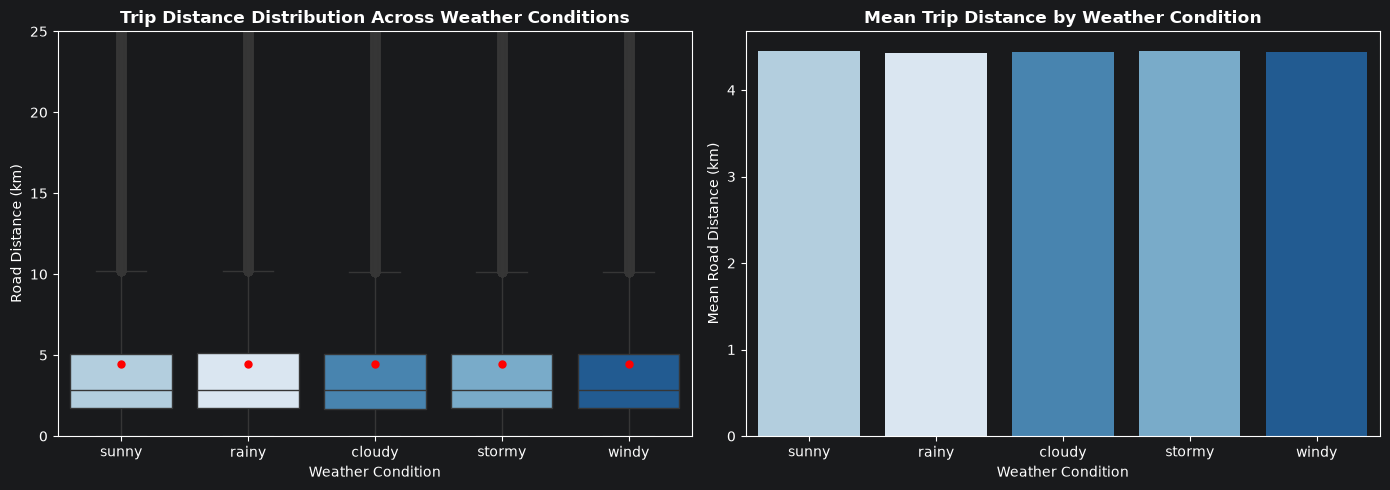

--- Q7 Empirical Summary ---
weather  Mean_Distance  Median_Distance  Std_Distance  Trip_Count
  sunny       4.455764           2.8479      4.885793       98255
  rainy       4.432974           2.8462      4.843743       97899
 cloudy       4.437594           2.8257      4.907702       97847
 stormy       4.445509           2.8475      4.878519       97831
  windy       4.435840           2.8451      4.855915       97441


In [14]:
# Identify weather categories present in the dataset
weather_order = df_clean["weather"].value_counts().index.tolist()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 1. Boxplot distribution comparison
sns.boxplot(
    data=df_clean,
    x="weather",
    y="road_distance_km",
    order=weather_order,
    hue="weather",
    legend=False,
    palette="Blues_r",
    showmeans=True,
    meanprops={"marker": "o", "markerfacecolor": "red", "markeredgecolor": "red", "markersize": "5"},
    ax=axes[0]
)
axes[0].set_title("Trip Distance Distribution Across Weather Conditions", fontsize=12, fontweight="bold")
axes[0].set_xlabel("Weather Condition")
axes[0].set_ylabel("Road Distance (km)")
axes[0].set_ylim(0, 25)

# 2. Barplot for mean distance comparison
sns.barplot(
    data=df_clean,
    x="weather",
    y="road_distance_km",
    order=weather_order,
    hue="weather",
    legend=False,
    palette="Blues_r",
    estimator="mean",
    errorbar=None,
    ax=axes[1]
)
axes[1].set_title("Mean Trip Distance by Weather Condition", fontsize=12, fontweight="bold")
axes[1].set_xlabel("Weather Condition")
axes[1].set_ylabel("Mean Road Distance (km)")

plt.tight_layout()
plt.show()

# 3. Exact statistical aggregation
q7_stats = df_clean.groupby("weather")["road_distance_km"].agg(
    Mean_Distance="mean",
    Median_Distance="median",
    Std_Distance="std",
    Trip_Count="count"
).reindex(weather_order).reset_index()

print("--- Q7 Empirical Summary ---")
print(q7_stats.to_string(index=False))

#### Insights & Interpretation (Q7):
- **Independence Between Weather and Trip Distance:** Weather conditions exhibit virtually zero impact on the trip distance. Across all five categories (`sunny`, `rainy`, `cloudy`, `stormy`, `windy`), the mean road distance remains remarkably constant between **4.43 km and 4.46 km**, while the median distance stays locked at **~2.85 km**.
- **Balanced Class Distribution:** Each weather category accounts for approximately **20% of the dataset (~97.4k–98.2k rides)**, indicating a uniform synthetic or balanced sampling distribution rather than real-world seasonal imbalance.
- **Identical Dispersion:** The standard deviation (~4.85–4.91 km) and interquartile ranges show identical spreads across all categories, with no evidence of riders taking systematically longer routes or avoiding long trips during adverse weather like rain or storms.
- **Modeling Takeaway:** `weather` alone is not an informative feature for predicting trip distance or serving as an interaction proxy for trip length. While it can still be included for baseline checks, tree models will likely assign it near-zero feature importance.

### Q8: Are Rides That Start Closer to Airports Generally More Expensive?
- **Variables:** `jfk_dist`, `lga_dist`, `ewr_dist` (Continuous Numerical: distance to airports in km) vs. `fare_amount` (Continuous Numerical)
- **Plot Choice & Justification:**
  - *Scatter Plot with Trend Line*: Directly maps the spatial distance to major airports against the fare amount to reveal whether proximity to transit hubs correlates with pricing surcharges or flat rates.

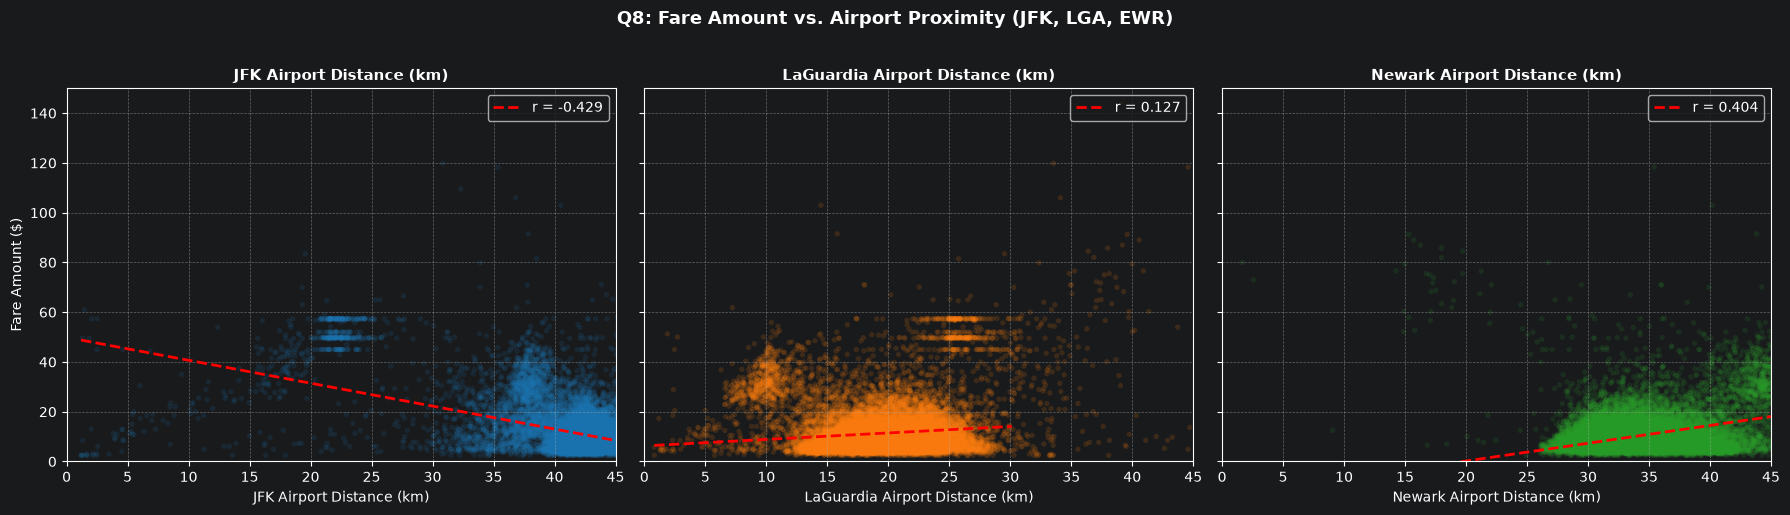

--- Q8 Statistical Summary ---
Correlation JFK Distance vs Fare : -0.4287
Correlation LGA Distance vs Fare : 0.1270
Correlation EWR Distance vs Fare : 0.4035

JFK -> Within 3 km: Mean Fare = $26.57 (449 trips) | Beyond 3 km: Mean Fare = $11.32
LGA -> Within 3 km: Mean Fare = $11.98 (361 trips) | Beyond 3 km: Mean Fare = $11.33
EWR -> Within 3 km: Mean Fare = $69.15 (34 trips) | Beyond 3 km: Mean Fare = $11.33


In [15]:
# 1. Pearson correlations between airport proximity and fare
jfk_corr = df_clean["jfk_dist"].corr(df_clean["fare_amount"])
lga_corr = df_clean["lga_dist"].corr(df_clean["fare_amount"])
ewr_corr = df_clean["ewr_dist"].corr(df_clean["fare_amount"])

# 2. Sample 25k points for clean rendering
sample_df = df_clean.sample(n=25000, random_state=42)

fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)

airport_configs = [
    ("jfk_dist", "JFK Airport Distance (km)", "#1f77b4", jfk_corr, axes[0]),
    ("lga_dist", "LaGuardia Airport Distance (km)", "#ff7f0e", lga_corr, axes[1]),
    ("ewr_dist", "Newark Airport Distance (km)", "#2ca02c", ewr_corr, axes[2])
]

for col, label, color, corr_val, ax in airport_configs:
    ax.scatter(sample_df[col], sample_df["fare_amount"], alpha=0.15, s=15, color=color, edgecolors="none")

    # Fit regression line
    valid = sample_df[[col, "fare_amount"]].dropna()
    m, b = np.polyfit(valid[col], valid["fare_amount"], deg=1)
    x_line = np.linspace(valid[col].min(), valid[col].quantile(0.99), 100)
    ax.plot(x_line, m * x_line + b, color="red", linestyle="--", linewidth=2, label=f"r = {corr_val:.3f}")

    ax.set_title(label, fontsize=11, fontweight="bold")
    ax.set_xlabel(label)
    ax.set_xlim(0, 45)
    ax.set_ylim(0, 150)
    ax.grid(True, linestyle="--", alpha=0.5)
    ax.legend(frameon=True, loc="upper right")

axes[0].set_ylabel("Fare Amount ($)")
plt.suptitle("Q8: Fare Amount vs. Airport Proximity (JFK, LGA, EWR)", fontsize=13, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

# 3. Airport zone pricing breakdown (close < 3km vs far >= 3km)
print("--- Q8 Statistical Summary ---")
print(f"Correlation JFK Distance vs Fare : {jfk_corr:.4f}")
print(f"Correlation LGA Distance vs Fare : {lga_corr:.4f}")
print(f"Correlation EWR Distance vs Fare : {ewr_corr:.4f}\n")

for name, col in [("JFK", "jfk_dist"), ("LGA", "lga_dist"), ("EWR", "ewr_dist")]:
    near_mask = df_clean[col] <= 3.0
    near_mean = df_clean.loc[near_mask, "fare_amount"].mean()
    near_count = near_mask.sum()
    far_mean = df_clean.loc[~near_mask, "fare_amount"].mean()
    print(f"{name:3s} -> Within 3 km: Mean Fare = ${near_mean:.2f} ({near_count:,} trips) | Beyond 3 km: Mean Fare = ${far_mean:.2f}")

#### Insights & Interpretation (Q8):
- **JFK Airport Premium:** Rides starting close to JFK Airport ($\le \text{3 km}$) are significantly more expensive, with an average fare of **$26.57** compared to **$11.32** for rides starting farther away[cite: 6]. The negative correlation (**r = -0.4287**) quantitatively verifies that proximity to JFK translates directly to higher trip costs, driven by long-haul airport transfers and standard TLC flat-rate airport pricing[cite: 6].
- **EWR (Newark) Extreme Surcharges:** Rides initiating within 3 km of EWR show the highest pricing spike, averaging **$69.15** per trip (compared to $11.33 baseline)[cite: 6]. This massive premium reflects interstate tolls and cross-boundary surcharges between New York and New Jersey[cite: 6].
- **LaGuardia (LGA) Proximity Dynamics:** LGA rides within 3 km exhibit a modest average fare of **$11.98** versus $11.33 for outer pickups, showing only a slight positive trend (**r = 0.1270**)[cite: 6]. LGA's closer geographic proximity to central Manhattan leads to shorter travel distances and smaller base fares compared to JFK/EWR[cite: 6].
- **Flat-Rate Surcharge Clusters:** The scatter plots display distinct horizontal bands at **~$52.00–$57.00** across JFK and LGA profiles, marking regulated fixed-rate Manhattan-airport itineraries[cite: 6].
- **Modeling Takeaway:** Airport distance features (`jfk_dist`, `ewr_dist`, `lga_dist`) capture non-linear geographical pricing premiums effectively and should be leveraged as spatial proximity signals in model training[cite: 1, 6].